# Masks
We can create a boolean array based on a condition and mask the pixels (hide, show or modify them) based on whether is truthy or falsy

Mask type: bool


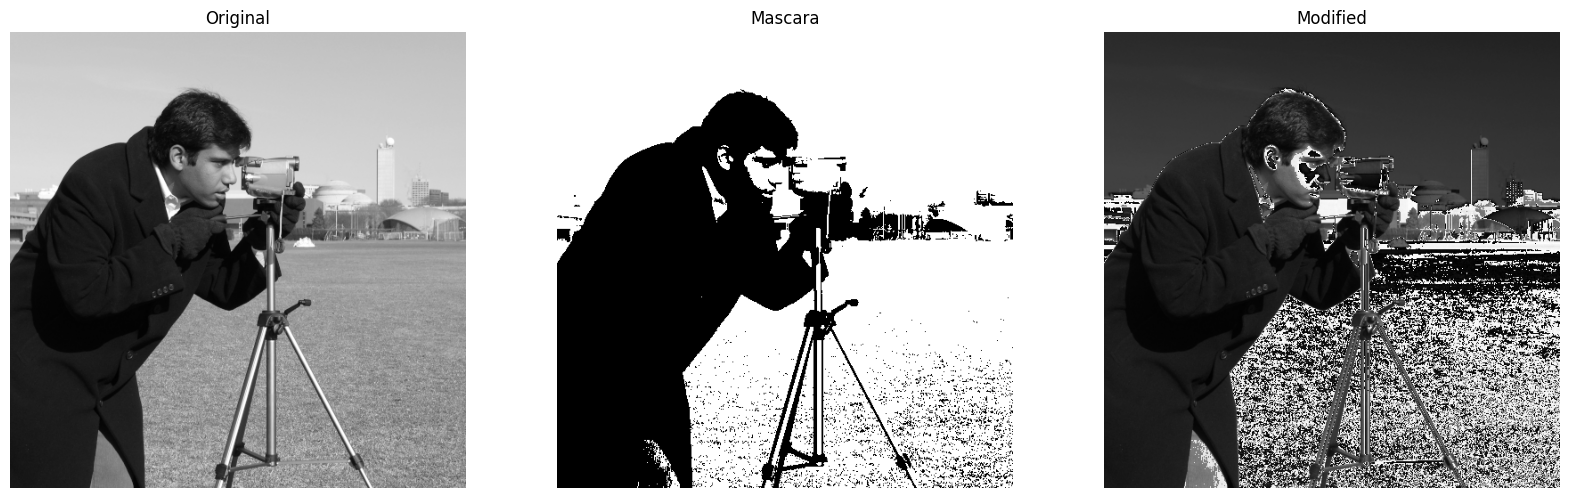

In [105]:
from skimage import data
import numpy as np
import matplotlib.pyplot as plt

img_camera = data.camera()

#A pixel on mask is true iff is greater than the mean
mean_mask = img_camera > np.mean(img_camera)

img_modified = img_camera.copy()

#Boolean indexing, only affects on true values
img_modified[mean_mask] += 100

print(f"Mask type: {mean_mask.dtype}")

fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(20,20))
ax1.set_title("Original")
ax1.axis("off")
ax1.imshow(img_camera, cmap="gray")

ax2.set_title("Mascara")
ax2.axis("off")
ax2.imshow(mean_mask, cmap="gray")

ax3.set_title("Modified")
ax3.axis("off")
ax3.imshow(img_modified, cmap="gray")
plt.show()

We can also mask on shapes

nrows: 512, ncols: 512
Center row: 206.0, Center col: 236.0


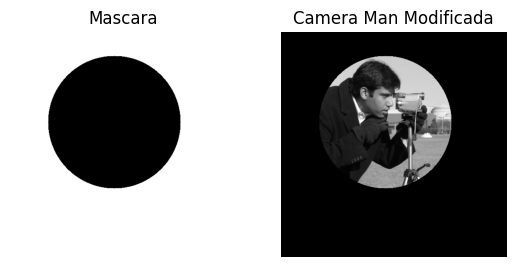

In [106]:
img_camera = data.camera()

nrows, ncols = img_camera.shape
print(f"nrows: {nrows}, ncols: {ncols}")

# an array of dim (height, 1) and (1, witdh)
rows, cols = np.ogrid[:nrows, :ncols]
#print(f"Rows: {rows}, Cols: {cols}")


# Radious mask with displacement
centerRow = (nrows / 2) - 50
centerCol = (ncols / 2) - 20
print(f"Center row: {centerRow}, Center col: {centerCol}")

mask_outside_disk = (rows - centerRow)**2 + (cols - centerCol)**2 > 150**2

img_camera[mask_outside_disk] = 0

fig, (ax1, ax2) = plt.subplots(1,2)
ax1.set_title("Mascara")
ax1.axis("off")
ax1.imshow(mask_outside_disk, cmap="gray")

ax2.set_title("Camera Man Modificada")
ax2.axis("off")
ax2.imshow(img_camera, cmap="gray")
plt.show()

In [107]:
# an array of dim (height, 1) and (1, witdh)
rows, cols = np.ogrid[:5, :5]
print(f"Rows: {rows}, Cols: {cols}")

# Radious mask
centerRow = 2
centerCol = 2
print(f"Center row: {centerRow}, Center col: {centerCol}")

mask_outside_disk = (rows - centerRow)**2 + (cols - centerCol)**2 > 150**2
print((rows - centerRow)**2 + (cols - centerCol)**2)
print("------------------------------")
# Radious mask
centerRow = 3
centerCol = 3
print(f"Center row: {centerRow}, Center col: {centerCol}")

mask_outside_disk = (rows - centerRow)**2 + (cols - centerCol)**2 > 150**2
print((rows - centerRow)**2 + (cols - centerCol)**2)

Rows: [[0]
 [1]
 [2]
 [3]
 [4]], Cols: [[0 1 2 3 4]]
Center row: 2, Center col: 2
[[8 5 4 5 8]
 [5 2 1 2 5]
 [4 1 0 1 4]
 [5 2 1 2 5]
 [8 5 4 5 8]]
------------------------------
Center row: 3, Center col: 3
[[18 13 10  9 10]
 [13  8  5  4  5]
 [10  5  2  1  2]
 [ 9  4  1  0  1]
 [10  5  2  1  2]]


Ill try to do a vignete style

nrows: 512, ncols: 512
[[ 98132.  97661.  97192. ... 116965. 117512. 118061.]
 [ 97721.  97250.  96781. ... 116554. 117101. 117650.]
 [ 97312.  96841.  96372. ... 116145. 116692. 117241.]
 ...
 [147505. 147034. 146565. ... 166338. 166885. 167434.]
 [148112. 147641. 147172. ... 166945. 167492. 168041.]
 [148721. 148250. 147781. ... 167554. 168101. 168650.]]


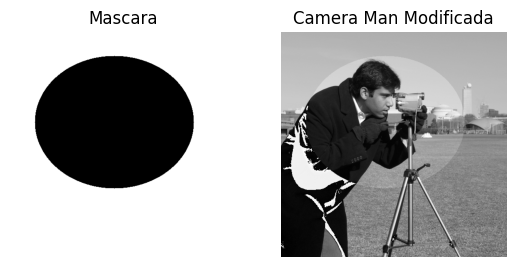

In [108]:
img_camera = data.camera()

nrows, ncols = img_camera.shape
print(f"nrows: {nrows}, ncols: {ncols}")

rows, cols = np.ogrid[:nrows, :ncols]

# Oval mask
centerRow = (nrows / 2) - 50
centerCol = (ncols / 2) - 20
vertical_radious = 150
horizontal_radious = 180

mask_outside_disk = ((rows - centerRow)**2 / vertical_radious**2) + ((cols - centerCol)**2 / horizontal_radious**2) > 1
print((rows - centerRow)**2 + (cols - centerCol)**2)

img_camera[mask_outside_disk] -= 20

fig, (ax1, ax2) = plt.subplots(1,2)
ax1.set_title("Mascara")
ax1.axis("off")
ax1.imshow(mask_outside_disk, cmap="gray")

ax2.set_title("Camera Man Modificada")
ax2.axis("off")
ax2.imshow(img_camera, cmap="gray")
plt.show()

Ill try to substract from the distance we took

In [109]:
# an array of dim (height, 1) and (1, witdh)
rows, cols = np.ogrid[:10, :10]
print(f"Rows: {rows}, Cols: {cols}")

# Radious mask
centerRow = 4
centerCol = 4
vertical_radious = 0.5
horizontal_radious = 1
print(f"Center row: {centerRow}, Center col: {centerCol}")

distance = ((rows - centerRow)**2 / vertical_radious**2) + ((cols - centerCol)**2 / horizontal_radious**2)
mask_outside_disk = distance > 1
print(distance)

Rows: [[0]
 [1]
 [2]
 [3]
 [4]
 [5]
 [6]
 [7]
 [8]
 [9]], Cols: [[0 1 2 3 4 5 6 7 8 9]]
Center row: 4, Center col: 4
[[ 80.  73.  68.  65.  64.  65.  68.  73.  80.  89.]
 [ 52.  45.  40.  37.  36.  37.  40.  45.  52.  61.]
 [ 32.  25.  20.  17.  16.  17.  20.  25.  32.  41.]
 [ 20.  13.   8.   5.   4.   5.   8.  13.  20.  29.]
 [ 16.   9.   4.   1.   0.   1.   4.   9.  16.  25.]
 [ 20.  13.   8.   5.   4.   5.   8.  13.  20.  29.]
 [ 32.  25.  20.  17.  16.  17.  20.  25.  32.  41.]
 [ 52.  45.  40.  37.  36.  37.  40.  45.  52.  61.]
 [ 80.  73.  68.  65.  64.  65.  68.  73.  80.  89.]
 [116. 109. 104. 101. 100. 101. 104. 109. 116. 125.]]


nrows: 512, ncols: 512
[[ 98132.  97661.  97192. ... 116965. 117512. 118061.]
 [ 97721.  97250.  96781. ... 116554. 117101. 117650.]
 [ 97312.  96841.  96372. ... 116145. 116692. 117241.]
 ...
 [147505. 147034. 146565. ... 166338. 166885. 167434.]
 [148112. 147641. 147172. ... 166945. 167492. 168041.]
 [148721. 148250. 147781. ... 167554. 168101. 168650.]]


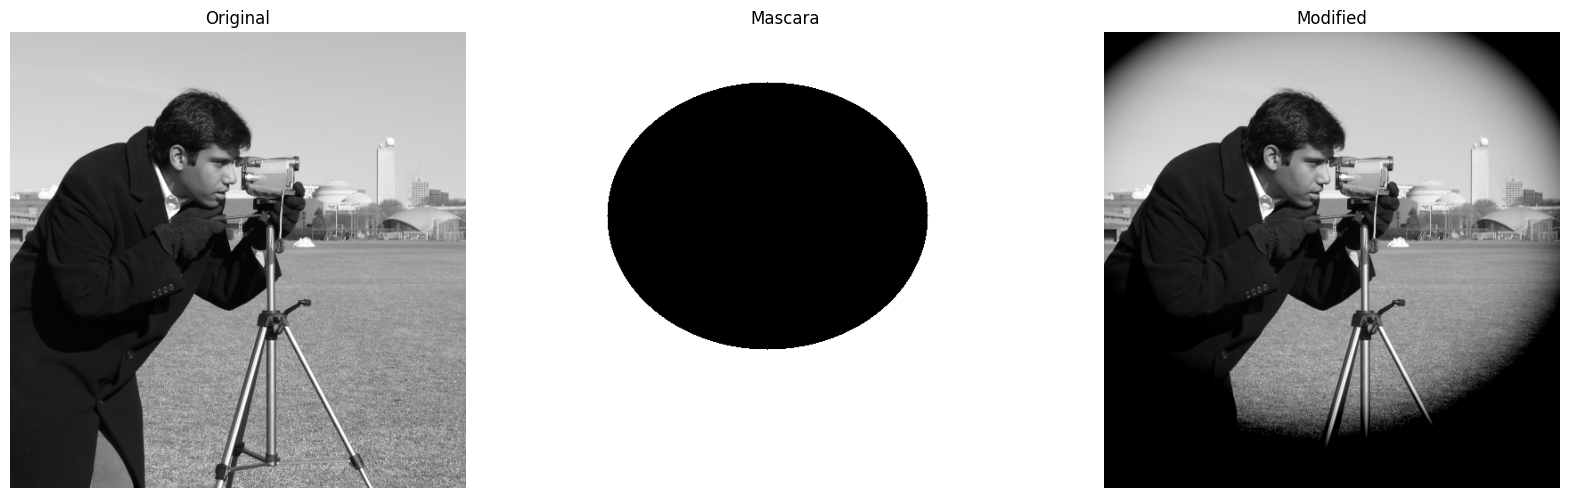

In [110]:
img_camera = data.camera()

nrows, ncols = img_camera.shape
print(f"nrows: {nrows}, ncols: {ncols}")

rows, cols = np.ogrid[:nrows, :ncols]

# Oval mask
centerRow = (nrows / 2) - 50
centerCol = (ncols / 2) - 20
vertical_radious = 150
horizontal_radious = 180

distance = ((rows - centerRow)**2 / vertical_radious**2) + ((cols - centerCol)**2 / horizontal_radious**2)
mask_outside_disk = ((rows - centerRow)**2 / vertical_radious**2) + ((cols - centerCol)**2 / horizontal_radious**2) > 1
print((rows - centerRow)**2 + (cols - centerCol)**2)

img_modified = img_camera.copy().astype(float) #distance is float type
distance **= 5 # increase effect
img_modified[mask_outside_disk] -= distance[mask_outside_disk]
img_modified = np.clip(img_modified, 0, 255)

fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(20,20))
ax1.set_title("Original")
ax1.axis("off")
ax1.imshow(img_camera, cmap="gray")

ax2.set_title("Mascara")
ax2.axis("off")
ax2.imshow(mask_outside_disk, cmap="gray")

ax3.set_title("Modified")
ax3.axis("off")
ax3.imshow(img_modified, cmap="gray")
plt.show()